In [52]:
import sys
import re
import os
import cv2
import numpy as np
import ipywidgets as widgets
import matplotlib.pyplot as plt
import glob
import random
from pathlib import Path

In [36]:
import torch
from torch import nn

from torch.utils.data import DataLoader
from torch.utils.data import Dataset

from torchvision import datasets, transforms
from torchvision.utils import make_grid

# Note: this notebook requires torch >= 1.10.0
torch.__version__

'2.12.1+cu130'

In [3]:
# Setup device-agnostic code
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

1. Configure Base Paths

In [4]:
ROOT_DIR = Path.cwd().parent.parent
sys.path.insert(0, str(ROOT_DIR / "src"))

print(ROOT_DIR)

/home/samuel-linux/master-degree-project


In [5]:
DATA_PATH = ROOT_DIR / "data" / "UCF_Crime" / "raw"
DATA_PATH

PosixPath('/home/samuel-linux/master-degree-project/data/UCF_Crime/raw')

In [6]:
class_names = os.listdir(DATA_PATH)
class_names

['RoadAccidents',
 'Assault',
 'Arrest',
 'Arson',
 'Shooting',
 'Stealing',
 'Burglary',
 'Robbery',
 'Shoplifting',
 'Fighting',
 'Abuse',
 'Explosion',
 'Vandalism']

In [7]:
videos_path = DATA_PATH / class_names[2]
videos = list(videos_path.glob("*.mp4"))[0]
videos

PosixPath('/home/samuel-linux/master-degree-project/data/UCF_Crime/raw/Arrest/Arrest017_x264.mp4')

2. Explore Dataset

In [8]:
def dataset_frames_labels(dataset_path: Path, rand_num: int):
  frames = []
  labels = []
  
  classes_names = os.listdir(dataset_path)
  
  for class_name in classes_names:
    videos_path = dataset_path / class_name
    video_path = list(videos_path.glob("*.mp4"))[rand_num]
  
    cap = cv2.VideoCapture(video_path)
    
    if not cap.isOpened():
      print("Error: Could not open the video file.")
      return
      
    ret, frame = cap.read()
    
    if not ret:
      break
    
    frames.append(frame)
    labels.append(video_path.name)
    
  return frames, labels
        
        

In [9]:
rand_num = random.randint(10, 50)

frames, labels = dataset_frames_labels(dataset_path=DATA_PATH, rand_num=rand_num) # type: ignore

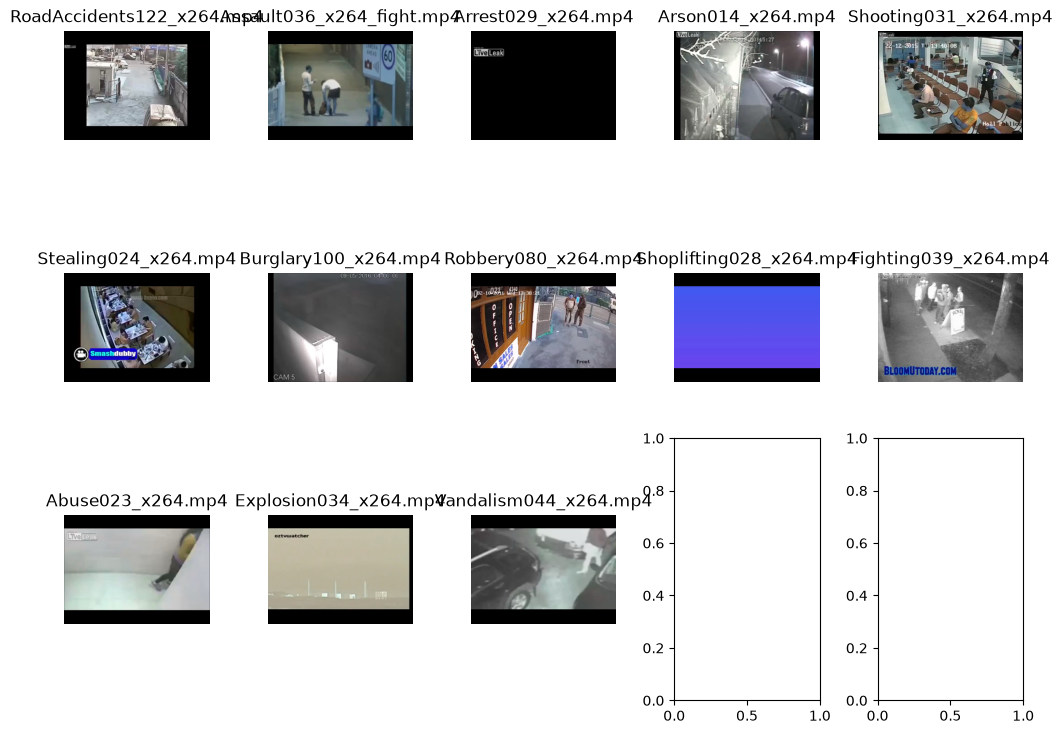

In [10]:
fig, axes = plt.subplots(3, 5, figsize=(10, 8))

for ax, frame, label in zip(axes.flatten(), frames, labels):
  ax.imshow(frame)
  ax.set_title(label)
  ax.axis("off")

plt.tight_layout()
plt.show()

3. Custom Dataset

In [14]:
class CustomVideoDataset(Dataset):
  def __init__(self, root_dir, num_frames=16, transform=None):
    """
    Args:
        root_dir (str): Path to the dataset directory (e.g., 'my_video_dataset/training')
        num_frames (int): Number of frames to sample from each video.
        transform (callable, optional): PyTorch transforms to apply to each frame.
    """
    self.root_dir = root_dir
    self.num_frames = num_frames
    self.transform = transform
      
    # Get class names and map them to integers
    self.classes = sorted(os.listdir(root_dir))
    self.class_to_idx = {cls_name: i for i, cls_name in enumerate(self.classes)}
      
    # Gather all video file paths and labels
    self.video_samples = []
    for cls_name in self.classes:
      cls_dir = os.path.join(root_dir, cls_name)
      if os.path.isdir(cls_dir):
        for file_name in os.listdir(cls_dir):
          if file_name.lower().endswith(('.mp4', '.avi', '.mov', '.mkv')):
            self.video_samples.append((os.path.join(cls_dir, file_name), self.class_to_idx[cls_name]))

  def __len__(self):
    return len(self.video_samples)

  def __getitem__(self, idx):
    video_path, label = self.video_samples[idx]
    
    # Capture frames from video
    cap = cv2.VideoCapture(video_path)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    
    if total_frames <= 0:
      raise ValueError(f"Error loading video or empty video file: {video_path}")
        
    # Calculate uniformly spaced frame indices
    seg_size = max(1, total_frames // self.num_frames)
    frame_indices = [min(total_frames - 1, i * seg_size) for i in range(self.num_frames)]
    
    frames = []
    for f_idx in frame_indices:
      cap.set(cv2.CAP_PROP_POS_FRAMES, f_idx)
      success, frame = cap.read()
      if not success:
        # Fallback to an empty/black frame if reading fails midway
        frame = torch.zeros((3, 224, 224)) if not self.transform else None
      else:
        # Convert BGR (OpenCV default) to RGB
        frame = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        if self.transform:
          frame = self.transform(frame)
              
      frames.append(frame)
        
    cap.release()
    
    # Stack frames into a single tensor
    # If your model expects shape (C, T, H, W) for 3D CNNs like ResNet3D:
    # permute channels after stacking.
    video_tensor = torch.stack(frames) # Shape: (T, C, H, W)
    video_tensor = video_tensor.permute(1, 0, 2, 3) # Shape: (C, T, H, W)
    
    return video_tensor, torch.tensor(label, dtype=torch.long)

In [15]:
# 1. Define Image/Frame transforms
# Video classification models typically require ImageNet or Kinetics normalization scales.
video_transforms = transforms.Compose([
  transforms.ToPILImage(),
  transforms.Resize((224, 224)),
  transforms.ToTensor(),
  transforms.Normalize(mean=[0.432, 0.394, 0.376], std=[0.228, 0.221, 0.216])
])

In [16]:
# 2. Instantiate Dataset
dataset = CustomVideoDataset(
  root_dir=DATA_PATH, 
  num_frames=16, 
  transform=video_transforms
)

In [19]:
# 3. Create DataLoader
dataloader = DataLoader(dataset, batch_size=32, shuffle=True, num_workers=2)

In [ ]:
# Get one video sample from dataloader
video, label = next(iter(dataloader))

In [53]:
label

'Vandalism044_x264.mp4'

In [55]:
label_re = re.split(r"[0-9]+", label)[0]
label_re

'Vandalism'

In [42]:
video.shape

torch.Size([32, 3, 16, 224, 224])

In [58]:
def video_dataloader_visualization(batch_of_videos, label, normalized=False):
  # First video in the batch
  sample = batch_of_videos[30]      # Shape: (3, 16, 224, 224)

  # Move frames to first dimension
  sample = sample.permute(1, 2, 3, 0)   # (16, 224, 224, 3)

  fig, axes = plt.subplots(4, 4, figsize=(10, 10))

  for i, ax in enumerate(axes.flat):
    frame = sample[i]

    if normalized:
      mean = torch.tensor([0.485, 0.456, 0.406])
      std = torch.tensor([0.229, 0.224, 0.225])
      frame = frame * std + mean

    frame = frame.clamp(0, 1)

    ax.imshow(frame)
    ax.set_title(f"{label}: Frame {i+1}")
    ax.axis("off")

  plt.tight_layout()
  plt.show()

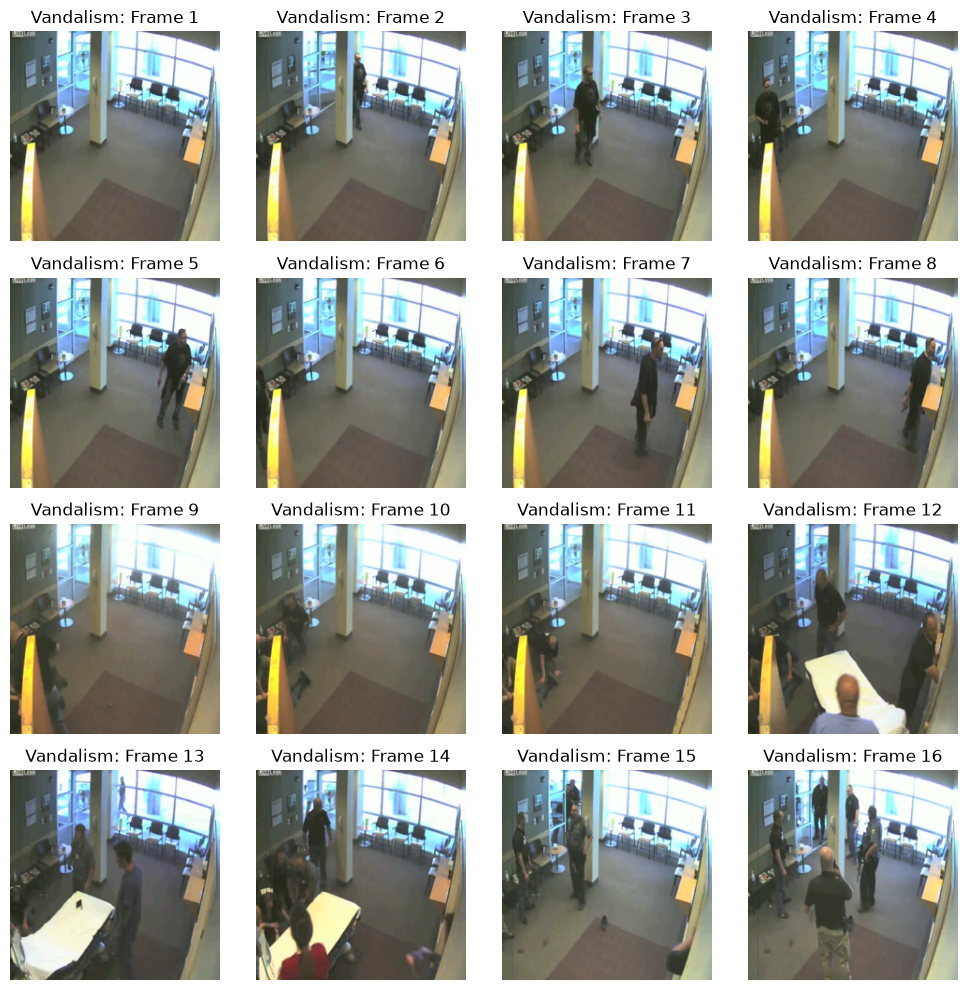

In [59]:
video_dataloader_visualization(video, label_re, normalized=True)

In [20]:
for videos, labels in dataloader:
  print("Batch Video Shape:", videos.shape) # Expected: [Batch, Channels, Frames, Height, Width]
  print("Batch Labels Shape:", labels.shape)
  break

Batch Video Shape: torch.Size([32, 3, 16, 224, 224])
Batch Labels Shape: torch.Size([32])
